In [1]:
import scipy.io
mat1 = scipy.io.loadmat('./kernel_1.mat')
mat2 = scipy.io.loadmat('./kernel_2.mat')
mat3 = scipy.io.loadmat('./kernel_3.mat')
mat4 = scipy.io.loadmat('./kernel_4.mat')
mat5 = scipy.io.loadmat('./Levin09blurdata/im06_flit03.mat')
mat6 = scipy.io.loadmat('./kernel_6.mat')
print(mat6.keys())  # See what's inside the file


dict_keys(['__header__', '__version__', '__globals__', 'kernel'])


In [2]:
data1 = mat1['kernel']
data2 = mat2['kernel']
data3 = mat3['kernel']
data4 = mat4['kernel']
data5 = mat5['f']
data6 = mat6['kernel']
data2.shape

(13, 13)

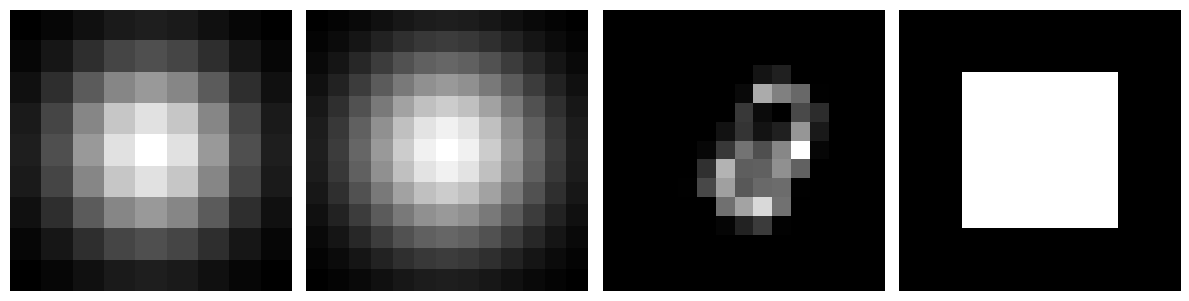

In [3]:
import matplotlib.pyplot as plt
from matplotlib import colors
import numpy as np

def pad_kernel(kernel, pad=2):
    size = kernel.shape[0] + 2 * pad
    background = np.zeros((size, size))
    background[pad:pad+kernel.shape[0], pad:pad+kernel.shape[1]] = kernel
    return background
data6_padded = pad_kernel(data6, pad=2)

data_list = [data1, data2, data5, data6_padded]
labels = ['(a)', '(b)', '(c)', '(d)']
fig, axes = plt.subplots(1, 4, figsize=(12, 6))
axes = axes.ravel()

for ax, data in zip(axes, data_list):
    im = ax.imshow(data, cmap='gray')
    ax.axis('off')

    # plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('kernels.png', dpi=300, bbox_inches='tight')

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def pad_kernel_to_size(kernel, target_size):
    h, w = kernel.shape
    background = np.zeros((target_size, target_size))
    y0 = (target_size - h) // 2
    x0 = (target_size - w) // 2
    background[y0:y0+h, x0:x0+w] = kernel
    return background
kernels = [data1, data2, data5, data6]
labels = ['a', 'b', 'c', 'd']

max_size = max(k.shape[0] for k in kernels) + 4  # margin
for kernel, label in zip(kernels, labels):
    padded = pad_kernel_to_size(kernel, max_size)

    fig, ax = plt.subplots(figsize=(3, 3))
    ax.imshow(padded, cmap='gray')
    ax.axis('off')

    plt.savefig(f'kernel_{label}.png', dpi=300, bbox_inches='tight', pad_inches=0)
    plt.close(fig)
